# Notebook 03 — Intro în Machine Learning și Rețele Neuronale

Ai parcurs Julia (nb 01) și hypergraphurile cu simulare ODE (nb 02). Acum facem **al treilea pas**: introducere în *machine learning* — domeniul care permite calculatorului să **învețe** din date, nu doar să execute formule pe care i le dăm noi.

**De ce un notebook dedicat ML?** Pentru că în notebook 04 vei vedea **Hypergraph Neural Networks**, o aplicație specifică de deep learning pe hypergraphuri. Fără să înțelegi întâi ce e o rețea neuronală, ce e *gradient descent*, ce e *training*, formulele HGNN sunt simboluri goale.

**Parcurs:**
0. **Notații matematice în Julia** — cum tastezi simbolurile pe care le vei vedea peste tot ($\alpha$, $\sigma$, $\theta$, $\hat{x}$, $\nabla$, etc.).
1. **Ce e ML?** — vocabular esențial.
2. **Regresie liniară** — cel mai simplu model ML, exemplificat cu **legea Beer-Lambert**.
3. **Funcția de cost + Gradient descent** — cum *învață* un model.
4. **De la regresie la rețele neuronale** — neuroni, MLP, neliniaritate, vizualizare arhitectură.
5. **Flux.jl** — un MLP real în Julia, antrenat pe date, cu **animație live a training-ului**.
6. **Convoluții** — overview CNN → GCN → HGNN (forward pointer la notebook 04).

## Cap. 0 — Notații matematice în Julia (Tab-completion magic)

Una dintre cele mai frumoase caracteristici ale Julia: **acceptă caractere Unicode native în nume**. Asta înseamnă că codul tău arată **exact ca formulele de pe hârtie**.

### Cum tastezi un simbol

În REPL Julia, Jupyter (cu kernel Julia) sau VS Code cu extensia Julia: scrii **secvența LaTeX** și apoi apeși **Tab**. Secvența se transformă în caracterul Unicode corespunzător.

**Exemplu:** tastează `\alpha` apoi Tab → obții `α`. Acesta e Unicode-ul U+03B1 (litera grecească alfa).

### Tabelul de bază (esențial pentru ML și chimie)

| Tastezi | Rezultat | Tipic folosit pentru |
|---|---|---|
| `\alpha<Tab>` | α | rate constants, learning rate |
| `\beta<Tab>` | β | coeficienți, momentum |
| `\gamma<Tab>` | γ | decay, discount factor |
| `\delta<Tab>` | δ | variații mici |
| `\epsilon<Tab>` | ε | toleranță, coeficient extincție |
| `\eta<Tab>` | η | learning rate (gradient descent) |
| `\theta<Tab>` | θ | parametri model (scalar) |
| `\Theta<Tab>` | Θ | matrice de parametri |
| `\lambda<Tab>` | λ | regularizare, valori proprii |
| `\mu<Tab>` | μ | medie, masa molară |
| `\sigma<Tab>` | σ | activare, deviație standard |
| `\Sigma<Tab>` | Σ | matrice de covarianță |
| `\rho<Tab>` | ρ | densitate, corelație |
| `\phi<Tab>` | φ | unghi diedru, latent variable |
| `\psi<Tab>` | ψ | unghi diedru, funcție de undă |
| `\Delta<Tab>` | Δ | diferență, pas de timp |
| `\nabla<Tab>` | ∇ | gradient |
| `\partial<Tab>` | ∂ | derivată parțială |
| `\pi<Tab>` | π | π (deja constantă built-in!) |

### Modificatori (combining marks) — se aplică peste un caracter

Tastezi **întâi caracterul de bază**, apoi modificatorul, apoi Tab.

| Tastezi | Rezultat | Folosit pentru |
|---|---|---|
| `x\bar<Tab>` | x̄ | **medie** (din statistică) |
| `x\hat<Tab>` | x̂ | **estimator** ($\hat{\theta}$ = $\theta$ estimat din date) |
| `x\dot<Tab>` | ẋ | prima derivată (notația Newton) |
| `x\ddot<Tab>` | ẍ | a doua derivată |
| `x\tilde<Tab>` | x̃ | aproximare, valoare "transformată" |
| `x\vec<Tab>` | x⃗ | vector |
| `x\prime<Tab>` | x′ | variabilă "primă" |

### Simboluri de mulțimi și logică

| Tastezi | Rezultat | Folosit pentru |
|---|---|---|
| `\in<Tab>` | ∈ | apartenență |
| `\subset<Tab>` | ⊂ | submulțime |
| `\cup<Tab>` | ∪ | reuniune |
| `\cap<Tab>` | ∩ | intersecție |
| `\forall<Tab>` | ∀ | "pentru orice" |
| `\exists<Tab>` | ∃ | "există" |
| `\sum<Tab>` | ∑ | sumă |
| `\prod<Tab>` | ∏ | produs |
| `\int<Tab>` | ∫ | integrală |
| `\infty<Tab>` | ∞ | infinit |
| `\sqrt<Tab>` | √ | radical |

> 💡 **Lista completă** la <https://docs.julialang.org/en/v1/manual/unicode-input/>. Are sute de simboluri.

### Demo: aceeași formulă, două scrieri

Implementăm $\sigma(z) = \frac{1}{1 + e^{-z}}$ (sigmoid) odată cu nume ASCII, odată cu Unicode native.

In [1]:
# Varianta 1 — ASCII (functionala dar urita)
function sigmoid_ascii(z)
    return 1 / (1 + exp(-z))
end

alpha = 0.01
theta_hat = [0.5, -0.3]
x_bar = 1.0
grad_L = [0.1, -0.2]

println("sigmoid(0.5) = ", sigmoid_ascii(0.5))
println("alpha * grad_L = ", alpha .* grad_L)

sigmoid(0.5) = 0.6224593312018546


alpha * grad_L = [0.001, -0.002]


In [2]:
# Varianta 2 — Unicode (citibila ca pe hartie)
# Taste: \sigma<Tab>, \alpha<Tab>, x\bar<Tab>, etc.

σ(z) = 1 / (1 + exp(-z))

α = 0.01           # learning rate
θ̂ = [0.5, -0.3]   # estimator pentru θ
x̄ = 1.0           # medie
∇L = [0.1, -0.2]   # gradient

println("σ(0.5) = ", σ(0.5))
println("α · ∇L = ", α .* ∇L)

σ(0.5) = 0.6224593312018546
α · ∇L = [0.001, -0.002]


Cele două celule fac **exact același lucru**. A doua e idiomatic Julia și mult mai apropiată de formulele matematice. **Folosește notația Unicode** — codul devine auto-documentat.

## Cap. 1 — Ce e Machine Learning?

**Programarea clasică:** scrii o funcție care, dată o intrare, produce o ieșire. Tu specifici explicit *cum* se calculează.

**Machine learning:** îi dai calculatorului **exemple** de intrări și ieșiri corecte (sau doar intrări) și el **învață singur** funcția. Tu specifici doar *forma* funcției (modelul) și *cât de bine* aproximă datele (loss function).

Vocabular esențial — la care vei reveni tot stagiul:

| Termen | Semnificație |
|---|---|
| **features (X)** | intrările modelului (vector de numere descriptori) |
| **labels (y)** | ieșirile dorite ("adevărul de aur") |
| **model** | funcția $f_\theta: X \to y$ cu parametri $\theta$ |
| **parametri $\theta$** | numerele care definesc modelul (ce *învățăm*) |
| **loss function $L$** | măsură de cât de greșite sunt predicțiile vs labels |
| **training** | căutarea $\theta^*$ care minimizează $L$ |
| **inference / predict** | aplicarea modelului antrenat pe date noi |

**Două tipuri mari de ML:**
- **Supervised learning** — ai *features* + *labels*. Ex: dată o moleculă, prezice solubilitatea.
- **Unsupervised learning** — ai doar *features*. Ex: grupează molecule similare.

În acest notebook lucrăm exclusiv pe **supervised**, cel mai răspândit caz practic.

## Cap. 2 — Regresie liniară: cel mai simplu model ML

### 2.1 Exemplu: legea Beer-Lambert

Pentru o soluție diluată, **absorbanța** $A$ măsurată cu un spectrofotometru e proporțională cu concentrația $c$:

$$A = \varepsilon \cdot \ell \cdot c$$

unde $\varepsilon$ e **coeficientul de extincție molară** (specific substanței la o lungime de undă) și $\ell$ e drumul optic.

**Întrebare de laborator:** ai măsurat 8 perechi $(c_i, A_i)$ pentru o substanță necunoscută. Cum afli $\varepsilon$?

**Răspuns ML:** fitezi o **regresie liniară** $A = m \cdot c + b$ (unde $m = \varepsilon \ell$ și $b \approx 0$ pentru blank corect). Asta e **deja un model ML** — învățăm parametrii $(m, b)$ din date.

In [3]:
using Random
Random.seed!(42)

concentratii = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]   # mM
ε_real = 5500.0   # mol⁻¹·cm⁻¹·L
ℓ = 1.0           # cm

absorbante = ε_real .* ℓ .* concentratii .* 1e-3 .+ 0.05 .* randn(length(concentratii))

for (c, A) in zip(concentratii, absorbante)
    println("c = $c mM, A = $(round(A; digits=3))")
end

c = 0.1 mM, A = 0.532
c = 0.2 mM, A = 1.113
c = 0.3 mM, A = 1.634
c = 0.4 mM, A = 2.184
c = 0.5 mM, A = 2.791
c = 0.6 mM, A = 3.324
c = 0.7 mM, A = 3.807
c = 0.8 mM, A = 4.327


### 2.2 Metoda celor mai mici pătrate (least squares)

Vrem $(m, b)$ care minimizează **suma erorilor pătratice**:

$$L(m, b) = \sum_{i=1}^N (A_i - (m \cdot c_i + b))^2$$

Soluția analitică (nu necesită iterații):

$$\hat{m} = \frac{\sum_i (c_i - \bar{c})(A_i - \bar{A})}{\sum_i (c_i - \bar{c})^2}, \quad \hat{b} = \bar{A} - \hat{m}\,\bar{c}$$

Implementare în Julia, cu notația Unicode din Cap. 0 (`x\bar<Tab>` pentru `x̄`, `m\hat<Tab>` pentru `m̂`):

In [4]:
function regresie_liniara(x, y)
    x̄, ȳ = sum(x)/length(x), sum(y)/length(y)
    m̂ = sum((x .- x̄) .* (y .- ȳ)) / sum((x .- x̄).^2)
    b̂ = ȳ - m̂ * x̄
    return m̂, b̂
end

m̂, b̂ = regresie_liniara(concentratii, absorbante)
println("Panta m̂ = $(round(m̂; digits=2))")
println("Interceptul b̂ = $(round(b̂; digits=4))")

ε_estimat = m̂ / (ℓ * 1e-3)
println("\nε_estimat = $(round(ε_estimat; digits=1))")
println("ε_real    = $ε_real")

Panta m̂ = 5.44
Interceptul b̂ = 0.0152

ε_estimat = 5441.7
ε_real    = 5500.0


Recuperăm $\varepsilon$ cu precizie bună chiar cu zgomot pe date. **Asta e ML în varianta cea mai simplă:** un model cu 2 parametri, antrenat pe 8 puncte, deja util în laborator.

**Limitări ale regresiei liniare:**
- Presupune relație liniară între intrări și ieșiri. Multe fenomene **nu sunt** (Michaelis-Menten, Langmuir, curbe de titrare, etc.).
- Are puțini parametri ⇒ capacitate mică de a învăța relații complexe.

Pentru relații neliniare avem nevoie de o metodă generală de optimizare: **gradient descent**.

## Cap. 3 — Funcția de cost și Gradient Descent

### 3.1 Loss function

**Loss function** $L(\theta)$ măsoară cât de greșite sunt predicțiile. Cel mai uzual: **mean squared error (MSE)**:

$$L(\theta) = \frac{1}{N} \sum_{i=1}^N (y_i - f_\theta(x_i))^2$$

**"Învățare" = minimizare a $L$ în raport cu $\theta$**. Vrem $\theta^* = \arg\min_\theta L(\theta)$.

### 3.2 Gradient Descent

Când $L$ e complicat, nu există soluție analitică. Folosim **iterativ**:

$$\theta_{t+1} = \theta_t - \eta \, \nabla_\theta L(\theta_t)$$

- $\nabla_\theta L$ = **gradient** — direcția de creștere maximă a $L$;
- $-\nabla_\theta L$ = direcția de **descreștere** (ce vrem);
- $\eta$ = **learning rate** (cât de mare e pasul).

**Intuiție:** ești într-o vale, vrei la fundul ei. La fiecare pas, mergi pe direcția în care terenul coboară cel mai abrupt.

Aplicăm GD pe Beer-Lambert ca să comparăm cu soluția analitică:

In [5]:
# Gradient descent pentru regresie liniara
# L(m, b) = mean((y - (m·x + b))²)
# ∂L/∂m = -2 · mean(x · (y - (m·x + b)))
# ∂L/∂b = -2 · mean(y - (m·x + b))

function gradient_descent(x, y; η=0.5, n_iter=2000)
    m, b = 0.0, 0.0
    losses = Float64[]
    
    for iter in 1:n_iter
        ŷ = m .* x .+ b
        err = y .- ŷ
        L = sum(err.^2) / length(x)
        push!(losses, L)
        
        ∂L_∂m = -2 * sum(x .* err) / length(x)
        ∂L_∂b = -2 * sum(err) / length(x)
        
        m -= η * ∂L_∂m
        b -= η * ∂L_∂b
    end
    return m, b, losses
end

m_gd, b_gd, losses = gradient_descent(concentratii, absorbante; η=0.5, n_iter=2000)
println("GD:        m = $(round(m_gd; digits=2)), b = $(round(b_gd; digits=4))")
println("Analitic:  m = $(round(m̂; digits=2)), b = $(round(b̂; digits=4))")
println("\nLoss inițial: $(round(losses[1]; digits=4))")
println("Loss final:   $(round(losses[end]; digits=6))")

GD:        m = 5.44, b = 0.0152
Analitic:  m = 5.44, b = 0.0152

Loss inițial: 7.6265
Loss final:   0.001006


GD recuperează aceeași soluție ca least squares analitic. **Asta e arhitectura de bază a oricărui training ML:**
1. Calculezi predicții;
2. Calculezi loss;
3. Calculezi gradient;
4. Actualizezi parametri în direcția opusă gradientului;
5. Repeți.

Pentru modele complexe, pașii 2-3 se fac automat prin **autodiff** — exact ce face Flux.jl, fără să mai derivăm noi cu pixelu'.

## Cap. 4 — De la regresie liniară la rețele neuronale

### 4.1 Un neuron = regresie liniară + activare neliniară

Un **neuron artificial** ia un vector de intrări $\vec{x}$, face o combinație liniară cu **ponderi** $\vec{w}$ și **bias** $b$, apoi aplică o **funcție de activare neliniară** $\sigma$:

$$y = \sigma(\vec{w}^\top \vec{x} + b)$$

Activări uzuale:
- **ReLU**: $\sigma(z) = \max(0, z)$ — cea mai răspândită.
- **tanh**: $\sigma(z) = \tanh(z)$ — în $[-1, 1]$.
- **sigmoid**: $\sigma(z) = 1/(1+e^{-z})$ — în $[0, 1]$.

**Neliniaritatea $\sigma$ e cheia.** Fără ea, oricâte layere ai stiva, rezultatul ar fi tot o transformare liniară.

### 4.2 Multi-Layer Perceptron (MLP)

$$\vec{x} \xrightarrow{W_1, b_1, \sigma} \vec{h}_1 \xrightarrow{W_2, b_2, \sigma} \vec{h}_2 \xrightarrow{\ldots} \vec{y}$$

Capacitatea crește cu adâncimea (mai multe layere) și lățimea (mai mulți neuroni per layer).

**De ce funcționează?** Teorema de aproximare universală [Cybenko, 1989]: un MLP cu un singur layer ascuns suficient de larg poate aproxima orice funcție continuă pe un compact.

### 4.3 Vizualizare: cum arată un MLP?

Înainte să-l antrenăm, vizualizăm structura. Definim o funcție utilitară care primește o listă de dimensiuni $[d_0, d_1, \ldots, d_L]$ și desenează rețeaua: cercuri pentru neuroni, linii pentru ponderi.

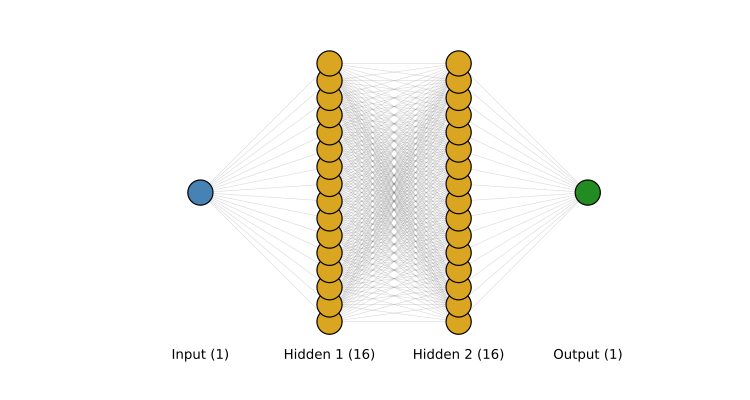

In [6]:
using Plots

function plot_mlp(layer_sizes; size=(750, 400))
    n_layers = length(layer_sizes)
    plt = plot(legend=false, aspect_ratio=:equal, grid=false,
               framestyle=:none, size=size,
               xlims=(0.5, n_layers+0.5), ylims=(-1.4, 1.4))
    
    layer_ys(s) = s == 1 ? [0.0] : collect(range(-1.0, 1.0; length=s))
    positions = [[(Float64(l), y) for y in layer_ys(s)] for (l, s) in enumerate(layer_sizes)]
    
    # Conexiuni intre layere consecutive
    for l in 1:n_layers-1
        for (x1, y1) in positions[l], (x2, y2) in positions[l+1]
            plot!(plt, [x1, x2], [y1, y2], color=:gray, alpha=0.3, lw=0.6)
        end
    end
    
    # Neuroni — input albastru, hidden auriu, output verde
    for (l, layer) in enumerate(positions)
        c = l == 1 ? :steelblue : (l == n_layers ? :forestgreen : :goldenrod)
        scatter!(plt, [p[1] for p in layer], [p[2] for p in layer],
                 color=c, ms=14, markerstrokewidth=1.5, markerstrokecolor=:black)
    end
    
    for l in 1:n_layers
        label = l == 1 ? "Input ($(layer_sizes[l]))" :
                l == n_layers ? "Output ($(layer_sizes[l]))" :
                "Hidden $(l-1) ($(layer_sizes[l]))"
        annotate!(plt, Float64(l), -1.25, text(label, 9, :center))
    end
    
    return plt
end

# Arhitectura pe care o vom antrena la Cap 5
plot_mlp([1, 16, 16, 1])

Citește graficul: **1 neuron de input** (x), **2 layere ascunse de câte 16 neuroni** (cu activare ReLU), **1 neuron de output** (predicția). Liniile cenușii sunt **ponderile** $W$ — fiecare e un număr învățabil. Total parametri:

$$(1 \cdot 16 + 16) + (16 \cdot 16 + 16) + (16 \cdot 1 + 1) = 32 + 272 + 17 = \textbf{321}$$

Toate cele 321 numere sunt ajustate prin gradient descent. Hai să o facem.

## Cap. 5 — Flux.jl: un MLP în Julia

**Flux.jl** [Innes, 2018] e framework-ul de deep learning nativ Julia. Filozofie: "differentiable programming" — scrii cod normal Julia, Flux îl diferențiază automat. Echivalentul lui PyTorch/TensorFlow din Python.

### Instalare (o singură dată)

In [7]:
using Pkg
Pkg.add("Flux")

   Resolving package versions...


     Project No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Manifest.toml`


In [8]:
using Flux
Random.seed!(42);

### 5.1 Construirea modelului

Aceeași arhitectură pe care am desenat-o mai sus (`[1, 16, 16, 1]`), în sintaxă Flux:

In [9]:
model = Chain(
    Dense(1 => 16, relu),    # input layer: 1 → 16 neuroni, activare ReLU
    Dense(16 => 16, relu),   # hidden layer: 16 → 16
    Dense(16 => 1)           # output layer: 16 → 1 (predictie scalara)
)

Chain(
  Dense(1 => 16, relu),                 # 32 parameters
  Dense(16 => 16, relu),                # 272 parameters
  Dense(16 => 1),                       # 17 parameters
)                   # Total: 6 arrays, 321 parameters, 1.559 KiB.

### 5.2 Date sintetice neliniare

Generăm date care **NU** pot fi aproximate de regresie liniară: $y = \sin(x) + 0.5x + \text{zgomot}$.

Contextul: $x$ = un descriptor continuu (temperatură, pH, log P), $y$ = o proprietate observată (randament, viteză, solubilitate).

In [10]:
xs = range(-3.0f0, 3.0f0; length=100)
ys_true = sin.(xs) .+ 0.5f0 .* xs
ys = ys_true .+ 0.1f0 .* randn(Float32, 100)

X = reshape(collect(xs), 1, :)   # 1 × 100
Y = reshape(ys, 1, :)             # 1 × 100

println("X shape: ", size(X))
println("Y shape: ", size(Y))

X shape: 

(1, 100)
Y shape: (1, 100)


### 5.3 Training loop

În Flux modern (v0.14+):
1. Definește o funcție loss;
2. Alege un **optimizer** (Adam — standard);
3. `Flux.setup` pregătește starea optimizer-ului;
4. În buclă: calculează gradient, aplică update.

In [11]:
loss_fn(m, x, y) = Flux.mse(m(x), y)

η = 0.01
opt = Adam(η)
opt_state = Flux.setup(opt, model)

losses_flux = Float64[]
for epoch in 1:500
    grads = gradient(m -> loss_fn(m, X, Y), model)[1]
    Flux.update!(opt_state, model, grads)
    push!(losses_flux, loss_fn(model, X, Y))
end

println("Loss initial: ", round(losses_flux[1]; digits=4))
println("Loss final:   ", round(losses_flux[end]; digits=6))
println("Reducere:     ", round(losses_flux[1] / losses_flux[end]; digits=1), "×")

Loss initial: 1.9376
Loss final:   0.008567
Reducere:     226.2×


### 5.4 Vizualizare: predicții și curba de loss

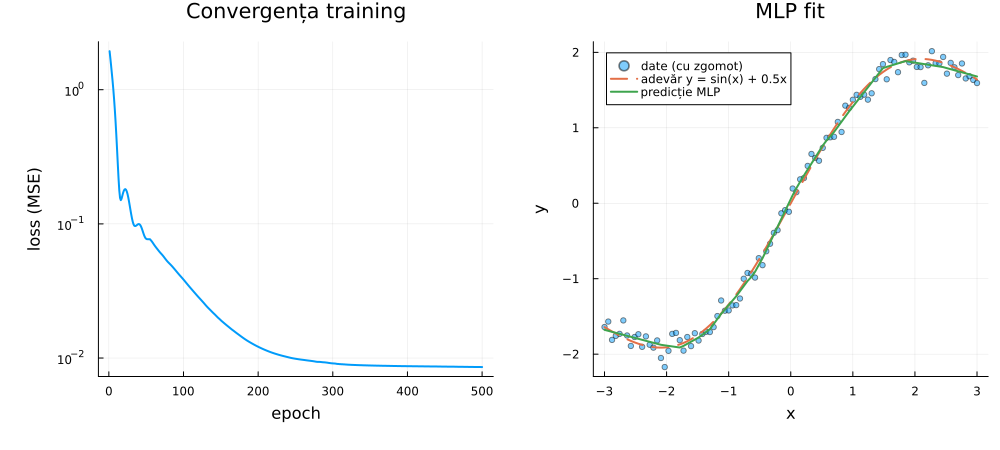

In [12]:
y_pred = vec(model(X))

p1 = plot(losses_flux,
    xlabel="epoch", ylabel="loss (MSE)", title="Convergența training",
    yscale=:log10, legend=false, lw=2)

p2 = scatter(vec(X), vec(Y), label="date (cu zgomot)", ms=3, alpha=0.5)
plot!(p2, vec(X), vec(ys_true), label="adevăr y = sin(x) + 0.5x", lw=2, ls=:dash)
plot!(p2, vec(X), y_pred, label="predicție MLP", lw=2)
plot!(p2, xlabel="x", ylabel="y", title="MLP fit")

plot(p1, p2, layout=(1,2), size=(1000, 450),
     left_margin=10Plots.mm, bottom_margin=10Plots.mm, top_margin=5Plots.mm)

**Observații:**
- Loss-ul scade exponențial pe scala log — caracteristic pentru un training sănătos.
- Predicția MLP urmărește îndeaproape adevărul $\sin(x) + 0.5x$, **chiar dacă nu am specificat această formă nicăieri**. Modelul a "învățat" forma din date.
- O regresie liniară ar fi o dreaptă — NU ar putea reproduce oscilația $\sin$. **Asta e diferența pe care o face neliniaritatea.**

### 5.5 🎬 Bonus — animație live a training-ului

Una dintre cele mai utile feature-uri pedagogice e să **vezi modelul cum învață, în timp real**. Julia are mai multe opțiuni pentru animații:

| Pachet | Pentru ce |
|---|---|
| **Plots.jl** (`@animate`/`@gif`) | cel mai simplu — buclă cu plot-uri, gata GIF |
| **Makie.jl** | 3D, interactiv, animații avansate |
| **Javis.jl** | stil 3Blue1Brown — animații cu obiecte și tranziții (când vrei să explici un concept abstract vizual) |
| **Luxor.jl** | grafică vectorială, combinabilă cu animații |

Pentru un grafic care se schimbă în timp (training curve), **Plots.jl `@animate`** e suficient. Reantrenăm modelul de la zero, captând fit-ul la fiecare 5 epoci:

[ Info: Saved animation to C:\Users\danmu\Documents\anastasia\notebooks\tmp.gif


Plots.AnimatedGif("C:\\Users\\danmu\\Documents\\anastasia\\notebooks\\tmp.gif")
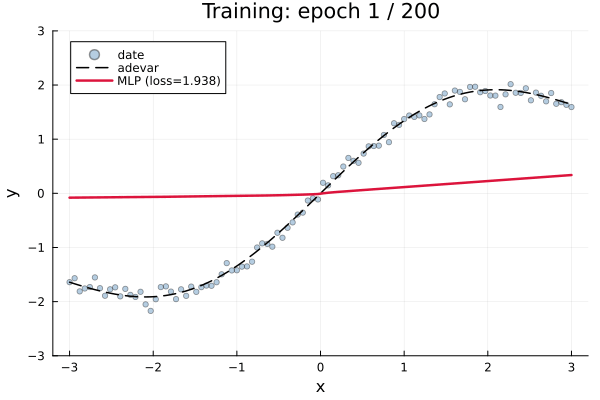

In [13]:
# Reinitializam de la zero ca sa vedem training-ul de la inceput
Random.seed!(42)
model_anim = Chain(Dense(1 => 16, relu), Dense(16 => 16, relu), Dense(16 => 1))
state_anim = Flux.setup(Adam(0.01), model_anim)

anim = @animate for epoch in 1:200
    grads = gradient(m -> Flux.mse(m(X), Y), model_anim)[1]
    Flux.update!(state_anim, model_anim, grads)
    L = Flux.mse(model_anim(X), Y)
    
    scatter(vec(X), vec(Y), label="date", ms=3, alpha=0.4,
            xlims=(-3.2, 3.2), ylims=(-3, 3), color=:steelblue)
    plot!(vec(X), vec(ys_true), label="adevar", lw=1.5, ls=:dash, color=:black)
    plot!(vec(X), vec(model_anim(X)),
          label="MLP (loss=$(round(L; digits=3)))", lw=2.5, color=:crimson)
    title!("Training: epoch $epoch / 200")
    xlabel!("x"); ylabel!("y")
end every 5

gif(anim, fps=10)

Privind animația vezi cum modelul:
1. **Începe** cu predicții aleatoare (zigzag-uri tăioase ReLU);
2. **Învață prima dată tendința liniară** (linia care merge de la stânga-jos la dreapta-sus);
3. **Apoi învață oscilațiile** ($\sin$) — fitarea fină.

Asta e o caracteristică observată empiric a rețelelor neuronale: **învață mai întâi structurile simple și pe urmă pe cele complexe** (o variantă de "spectral bias").

## Cap. 6 — Convoluții: spre arhitecturi specializate

MLP-urile lucrează pe **vectori plați** de features. Dar multe date au **structură** suplimentară:
- imaginile au structură **spațială 2D** (pixeli vecini sunt corelați);
- moleculele au structură de **graf** (atomi legați);
- complexele proteice au structură de **hypergraph** (subunități interacționează în grupuri).

### 6.1 CNN — Convolutional Neural Networks

**Idee centrală:** un filtru (kernel) mic glisează peste imagine, calculând produsul scalar cu fiecare patch. **Același filtru detectează același pattern oriunde apare** (translation equivariance).

Aplicații în chimie: clasificare de spectre 1D (NMR, IR), analiză imagini microscopie, hărți de densitate electronică.

Citații: [LeCun et al., 1998] (LeNet); [Krizhevsky et al., 2012] (AlexNet).

### 6.2 GCN — Graph Convolutional Networks

**Idee centrală:** fiecare nod își *agregază* features-urile de la vecini, trecute printr-o transformare liniară + activare. Formula [Kipf & Welling, 2017]:

$$X^{(l+1)} = \sigma\!\left( \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} X^{(l)} \Theta^{(l)} \right)$$

Aplicații în chimie: predicția proprietăților moleculare din SMILES, drug-target binding, retrosinteză.

### 6.3 HGNN — Hypergraph Neural Networks

**Idee centrală:** generalizarea naturală a GCN la **hypergraphuri**. Formula folosește matricea de incidență $H$ în loc de adiacență $A$:

$$X^{(l+1)} = \sigma\!\left( D_v^{-1/2} H W D_e^{-1} H^\top D_v^{-1/2} X^{(l)} \Theta^{(l)} \right)$$

**Asta vom explora în detaliu în notebook 04** — matematică, implementare manuală pe o rețea de complexe proteice, survey aplicații în proteomică.

**Trecerea importantă:** dacă în nb 02 hypergraphul a fost o **structură de date** și o **sursă pentru ODE**, în nb 04 el devine **substratul pentru deep learning**.

## Exerciții

Soluțiile sunt mai jos.

### Exercițiul 1 — Antrenare pe date diferite

Generează un dataset cu o formă diferită — de exemplu $y = x^2$ (parabolă) — și antrenează același MLP. Câte epoci sunt necesare pentru loss < 0.01? Vizualizează predicțiile.

In [14]:
# Scrie aici solutia ta — Exercitiul 1


### Exercițiul 2 — Capacitatea modelului

Antrenează 3 modele cu dimensiuni diferite ale layerului ascuns: 2, 16, 64 neuroni. Pe datele $y = \sin(x) + 0.5x$:
1. Care converge cel mai rapid?
2. Care obține loss-ul cel mai mic?
3. Vizualizează predicțiile și arhitecturile (folosește `plot_mlp` din Cap. 4.3).

In [15]:
# Scrie aici solutia ta — Exercitiul 2


### Exercițiul 3 — Regresie liniară vs MLP

Fitează regresia liniară (`regresie_liniara`) pe datele neliniare $y = \sin(x) + 0.5x$. Calculează MSE-ul rezidual. Compară cu MSE-ul final al MLP-ului din Cap. 5.

*Hint:* pentru regresia liniară pe date Float32, convertește la Float64 cu `Float64.(...)` întâi.

In [16]:
# Scrie aici solutia ta — Exercitiul 3


## Soluții

*Nu citi înainte să fi încercat singură.*

Epoci pana la loss < 0.01: 293
Loss final: 0.00678


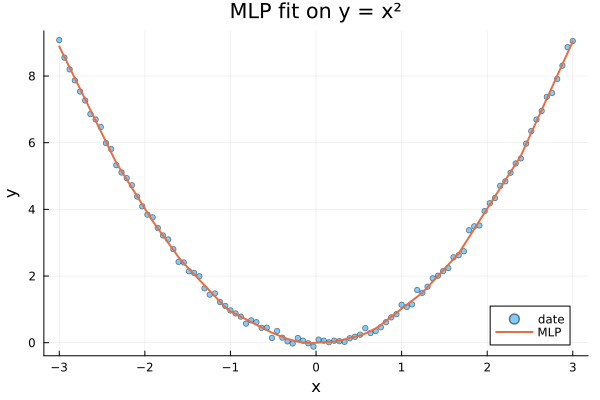

In [17]:
# Solutia 1 — MLP pe y = x²
Random.seed!(42)
xs2 = range(-3.0f0, 3.0f0; length=100)
ys2 = xs2.^2 .+ 0.1f0 .* randn(Float32, 100)
X2 = reshape(collect(xs2), 1, :)
Y2 = reshape(ys2, 1, :)

model2 = Chain(Dense(1 => 16, relu), Dense(16 => 16, relu), Dense(16 => 1))
state2 = Flux.setup(Adam(0.01), model2)

losses2 = Float64[]
epoch_to_001 = -1
for epoch in 1:1000
    grads = gradient(m -> Flux.mse(m(X2), Y2), model2)[1]
    Flux.update!(state2, model2, grads)
    L = Flux.mse(model2(X2), Y2)
    push!(losses2, L)
    if epoch_to_001 == -1 && L < 0.01
        epoch_to_001 = epoch
    end
end
println("Epoci pana la loss < 0.01: ", epoch_to_001)
println("Loss final: ", round(losses2[end]; digits=5))

scatter(vec(X2), vec(Y2), label="date", ms=3, alpha=0.5)
plot!(vec(X2), vec(model2(X2)), label="MLP", lw=2)
plot!(xlabel="x", ylabel="y", title="MLP fit on y = x²")

h = 2: loss final = 2.28867
h = 16: loss final = 0.00857


h = 64: loss final = 0.00759


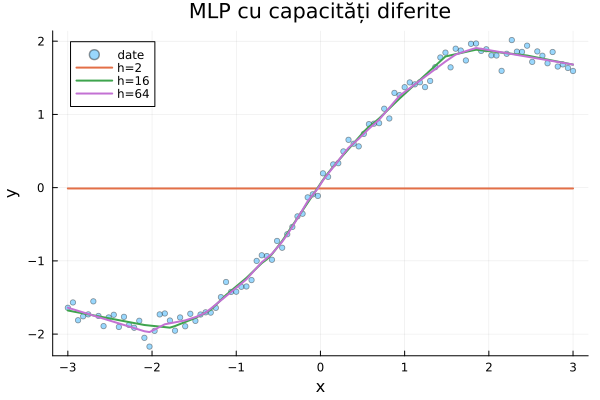

In [18]:
# Solutia 2 — capacitatea modelului
results = Dict{Int, Tuple{Float64, Vector{Float32}}}()

for h in (2, 16, 64)
    Random.seed!(42)
    m_h = Chain(Dense(1 => h, relu), Dense(h => h, relu), Dense(h => 1))
    state_h = Flux.setup(Adam(0.01), m_h)
    
    losses_h = Float64[]
    for epoch in 1:500
        grads = gradient(m -> Flux.mse(m(X), Y), m_h)[1]
        Flux.update!(state_h, m_h, grads)
        push!(losses_h, Flux.mse(m_h(X), Y))
    end
    results[h] = (losses_h[end], vec(m_h(X)))
    println("h = $h: loss final = ", round(losses_h[end]; digits=5))
end

scatter(vec(X), vec(Y), label="date", ms=3, alpha=0.4)
for h in (2, 16, 64)
    plot!(vec(X), results[h][2], label="h=$h", lw=2)
end
plot!(xlabel="x", ylabel="y", title="MLP cu capacități diferite")

MSE regresie liniara: 

0.18677
MSE MLP:              0.00857
Raport: MLP e de 21.8× mai bun


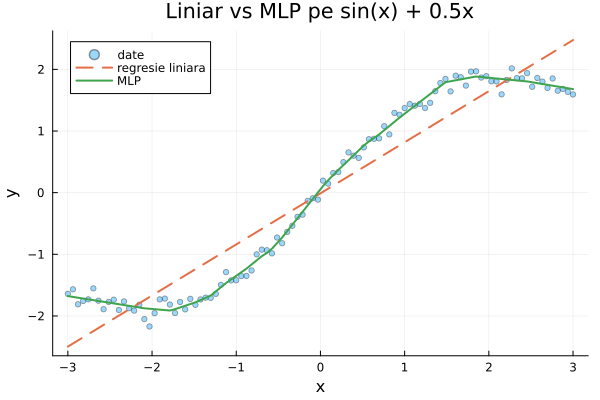

In [19]:
# Solutia 3 — regresie liniara vs MLP
x_lin = Float64.(vec(X))
y_lin = Float64.(vec(Y))

m_lin, b_lin = regresie_liniara(x_lin, y_lin)
y_lin_pred = m_lin .* x_lin .+ b_lin

mse_lin = sum((y_lin .- y_lin_pred).^2) / length(y_lin)
mse_mlp = Float64(losses_flux[end])

println("MSE regresie liniara: ", round(mse_lin; digits=5))
println("MSE MLP:              ", round(mse_mlp; digits=5))
println("Raport: MLP e de ", round(mse_lin / mse_mlp; digits=1), "× mai bun")

scatter(x_lin, y_lin, label="date", ms=3, alpha=0.4)
plot!(x_lin, y_lin_pred, label="regresie liniara", lw=2, ls=:dash)
plot!(vec(X), vec(model(X)), label="MLP", lw=2)
plot!(xlabel="x", ylabel="y", title="Liniar vs MLP pe sin(x) + 0.5x")

## Ce ai învățat în acest notebook

- ✅ **Notații Unicode native în Julia** — `α`, `σ`, `θ̂`, `x̄`, `∇`, `∂` cu Tab-completion. Cod auto-documentat.
- ✅ **Vocabular ML** — features, labels, model, loss, training, parametri, inference.
- ✅ **Regresie liniară** prin least squares (analitic).
- ✅ **Funcția de cost (MSE)** și **gradient descent** — metodă universală.
- ✅ **Neuroni și MLP** — un neuron e regresie + activare; o rețea e neuroni stratificați.
- ✅ **De ce neliniaritatea contează** — fără ea, oricâte layere = o singură regresie.
- ✅ **Vizualizare arhitectură MLP** — `plot_mlp` îți arată structura cu cercuri și linii.
- ✅ **Flux.jl** — Chain + Dense + Adam + training loop.
- ✅ **Animație training** cu `@animate` din Plots.jl — vezi modelul cum învață.
- ✅ **Convoluții specializate** — CNN → GCN → HGNN (urmează în nb 04).

**Următor pas:** notebook 04 — Hypergraph Neural Networks aplicate la complexe proteice.

## Referințe

### Notații Unicode
- **Julia documentation — Unicode Input:** <https://docs.julialang.org/en/v1/manual/unicode-input/>

### Fundamente ML
- **Cybenko, G. (1989).** Approximation by superpositions of a sigmoidal function. *Math. Control Signals Syst.*, 2(4), 303–314. [DOI](https://doi.org/10.1007/BF02551274) — aproximare universală.
- **Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986).** Learning representations by back-propagating errors. *Nature*, 323, 533–536. [DOI](https://doi.org/10.1038/323533a0) — backpropagation.
- **Kingma, D. P., & Ba, J. (2015).** Adam: A Method for Stochastic Optimization. *ICLR*. [arXiv:1412.6980](https://arxiv.org/abs/1412.6980)

### Cărți
- **Murphy, K. P. (2022).** *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/>
- **Goodfellow, I., Bengio, Y., & Courville, A. (2016).** *Deep Learning*. MIT Press. <https://www.deeplearningbook.org/>
- **Bishop, C. M. (2006).** *Pattern Recognition and Machine Learning*. Springer.

### Cursuri online (gratuite)
- **Stanford CS231n** — CNN. [website](https://cs231n.stanford.edu/) + [YouTube](https://www.youtube.com/playlist?list=PL3FW7Lu3i5JvHM8ljYj-zLfQRF3EO8sYv).
- **fast.ai** — *Practical Deep Learning for Coders*. <https://course.fast.ai/>
- **3Blue1Brown** — *Neural Networks* (YouTube), excelentă vizualizare. [seria](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi).

### Arhitecturi specializate
- **LeCun, Y., et al. (1998).** Gradient-based learning applied to document recognition. *Proc. IEEE*, 86(11), 2278–2324. — LeNet.
- **Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012).** ImageNet Classification with Deep CNNs. *NeurIPS*. — AlexNet.
- **Kipf, T. N., & Welling, M. (2017).** Semi-Supervised Classification with GCN. *ICLR*. [arXiv:1609.02907](https://arxiv.org/abs/1609.02907)

### Julia ML & vizualizare
- **Innes, M. (2018).** Flux: Elegant ML with Julia. *JOSS*, 3(25), 602. [DOI](https://doi.org/10.21105/joss.00602)
- **Flux.jl** — <https://fluxml.ai/Flux.jl/stable/>
- **Plots.jl** (`@animate`/`@gif`) — <https://docs.juliaplots.org/latest/animations/>
- **Makie.jl** — <https://docs.makie.org/> — 3D, interactive, animații avansate.
- **Javis.jl** — <https://juliaanimators.github.io/Javis.jl/> — stil 3Blue1Brown, animații educaționale cu obiecte și tranziții. *Util când vrei să explici un concept abstract vizual (de ex. message passing pe un hypergraph — îl vom folosi probabil în nb 04).*
- **Luxor.jl** — <https://juliagraphics.github.io/Luxor.jl/> — grafică vectorială.

### Vizualizare 3D pentru molecule și proteine (pentru notebook 04)
- **Bio3DView.jl** — <https://github.com/jgreener64/Bio3DView.jl> — wrapper interactiv 3Dmol.js pentru Jupyter, ideal pentru proteine.
- **BioStructures.jl** — <https://github.com/BioJulia/BioStructures.jl> — citire/manipulare PDB, calcule structurale.
- **MolecularGraph.jl** — <https://github.com/mojaie/MolecularGraph.jl> — SMILES → graf molecular, layout 2D/3D.
- **AtomsBase.jl** — <https://github.com/JuliaMolSim/AtomsBase.jl> — interfață standardizată pentru sisteme atomice.
- **Chemfiles.jl** — <https://github.com/chemfiles/Chemfiles.jl> — I/O pentru ~80 formate moleculare.